# Làm sạch, Chuẩn hóa & Đồng bộ Dữ liệu Thời tiết

**Mục tiêu**: Làm sạch dữ liệu thời tiết từ Meteostat, phát hiện bất thường, chuẩn hóa và đồng bộ thời gian.

**Nguồn dữ liệu**: `raw/meteostat_weather_data.csv`

**Kết quả**: 
- Dữ liệu đã làm sạch: `processed/weather_cleaned.csv`
- Báo cáo QA: `reports/qa_weather_summary.csv`

## 1. Import Libraries và Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load dữ liệu thời tiết
df_weather = pd.read_csv('../raw/meteostat_weather_data.csv')

print("="*70)
print("DỮ LIỆU THỜI TIẾT GÓC")
print("="*70)
print(f"Số dòng: {len(df_weather)}")
print(f"Số cột: {len(df_weather.columns)}")
print(f"\nCác cột: {list(df_weather.columns)}")
print(f"\nKiểu dữ liệu:")
print(df_weather.dtypes)
print(f"\n5 dòng đầu tiên:")
df_weather.head()

DỮ LIỆU THỜI TIẾT GÓC
Số dòng: 366
Số cột: 6

Các cột: ['time', 'temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 'wind_direction_deg', 'pressure_hPa']

Kiểu dữ liệu:
time                   object
temperature_avg_C     float64
precipitation_mm      float64
wind_speed_kmh        float64
wind_direction_deg    float64
pressure_hPa          float64
dtype: object

5 dòng đầu tiên:


,time,temperature_avg_C,precipitation_mm,wind_speed_kmh,wind_direction_deg,pressure_hPa
0,2024-01-01,28.2,0.0,6.2,NaN,1011.3
1,2024-01-02,28.6,0.0,6.3,NaN,1010.9
2,2024-01-03,28.6,0.0,7.1,NaN,1010.9
3,2024-01-04,28.2,0.0,6.8,NaN,1011.4
4,2024-01-05,27.7,0.0,5.1,NaN,1012.2


## 2. Chuyển đổi và Chuẩn hóa Thời gian

In [3]:
# Chuyển cột time sang datetime
df_weather['time'] = pd.to_datetime(df_weather['time'])

# Đặt time làm index
df_weather.set_index('time', inplace=True)

# Sắp xếp theo thời gian
df_weather.sort_index(inplace=True)

print("✓ Đã chuyển đổi cột time sang datetime và đặt làm index")
print(f"Khoảng thời gian: {df_weather.index.min()} đến {df_weather.index.max()}")
print(f"Số ngày: {len(df_weather)}")

df_weather.head()

✓ Đã chuyển đổi cột time sang datetime và đặt làm index
Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00
Số ngày: 366


,temperature_avg_C,precipitation_mm,wind_speed_kmh,wind_direction_deg,pressure_hPa
time,,,,,
2024-01-01,28.2,0.0,6.2,NaN,1011.3
2024-01-02,28.6,0.0,6.3,NaN,1010.9
2024-01-03,28.6,0.0,7.1,NaN,1010.9
2024-01-04,28.2,0.0,6.8,NaN,1011.4
2024-01-05,27.7,0.0,5.1,NaN,1012.2


## 3. Khởi tạo Báo cáo QA

In [4]:
# Tạo DataFrame để lưu báo cáo QA
qa_report = []

def add_qa_record(rule_name, issue_count, total_count, description, action_taken):
    """Thêm một bản ghi vào báo cáo QA"""
    percentage = (issue_count / total_count * 100) if total_count > 0 else 0
    qa_report.append({
        'Rule': rule_name,
        'Issues_Found': issue_count,
        'Total_Records': total_count,
        'Percentage': f"{percentage:.2f}%",
        'Description': description,
        'Action_Taken': action_taken
    })

print("✓ Đã khởi tạo hệ thống báo cáo QA")

✓ Đã khởi tạo hệ thống báo cáo QA


## 4. Kiểm tra Dữ liệu Thiếu (Missing Data)

In [5]:
print("="*70)
print("KIỂM TRA DỮ LIỆU THIẾU")
print("="*70)

missing_data = df_weather.isnull().sum()
missing_percentage = (missing_data / len(df_weather) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percentage
})

print(missing_summary)

# Thêm vào báo cáo QA
for col in df_weather.columns:
    missing_count = missing_data[col]
    if missing_count > 0:
        add_qa_record(
            rule_name=f"Missing_{col}",
            issue_count=missing_count,
            total_count=len(df_weather),
            description=f"Giá trị thiếu trong cột {col}",
            action_taken="Gắn cờ 'is_missing', giữ nguyên giá trị NaN để phân tích sau"
        )

# Tạo cờ cho dữ liệu thiếu
for col in df_weather.columns:
    df_weather[f'{col}_missing'] = df_weather[col].isnull().astype(int)

print("\n✓ Đã gắn cờ cho các giá trị thiếu")

KIỂM TRA DỮ LIỆU THIẾU
                    Missing_Count  Percentage
temperature_avg_C               0        0.00
precipitation_mm               12        3.28
wind_speed_kmh                  0        0.00
wind_direction_deg            366      100.00
pressure_hPa                    0        0.00

✓ Đã gắn cờ cho các giá trị thiếu


## 5. Kiểm tra Giá trị Âm Không Hợp lệ

In [6]:
print("="*70)
print("KIỂM TRA GIÁ TRỊ ÂM KHÔNG HỢP LỆ")
print("="*70)

# Các cột không được có giá trị âm
non_negative_cols = ['precipitation_mm', 'wind_speed_kmh']

for col in non_negative_cols:
    if col in df_weather.columns:
        negative_count = (df_weather[col] < 0).sum()
        print(f"{col}: {negative_count} giá trị âm")
        
        if negative_count > 0:
            add_qa_record(
                rule_name=f"Negative_{col}",
                issue_count=negative_count,
                total_count=len(df_weather),
                description=f"Giá trị âm không hợp lệ trong {col}",
                action_taken="Gắn cờ 'invalid_negative'"
            )
            
            # Gắn cờ
            df_weather[f'{col}_invalid_negative'] = (df_weather[col] < 0).astype(int)
            
            # Hiển thị các giá trị âm
            print(f"  Các giá trị âm trong {col}:")
            print(df_weather[df_weather[col] < 0][[col]])

print("\n✓ Đã kiểm tra giá trị âm")

KIỂM TRA GIÁ TRỊ ÂM KHÔNG HỢP LỆ
precipitation_mm: 0 giá trị âm
wind_speed_kmh: 0 giá trị âm

✓ Đã kiểm tra giá trị âm


## 6. Kiểm tra Áp suất Ngoài Ngưỡng

In [7]:
print("="*70)
print("KIỂM TRA ÁP SUẤT NGOÀI NGƯỠNG")
print("="*70)

# Ngưỡng hợp lý cho áp suất (hPa) ở TP.HCM
PRESSURE_MIN = 980  # hPa
PRESSURE_MAX = 1040 # hPa

if 'pressure_hPa' in df_weather.columns:
    invalid_pressure = ((df_weather['pressure_hPa'] < PRESSURE_MIN) | 
                       (df_weather['pressure_hPa'] > PRESSURE_MAX))
    invalid_count = invalid_pressure.sum()
    
    print(f"Ngưỡng hợp lệ: {PRESSURE_MIN} - {PRESSURE_MAX} hPa")
    print(f"Số giá trị ngoài ngưỡng: {invalid_count}")
    
    if invalid_count > 0:
        add_qa_record(
            rule_name="Pressure_OutOfRange",
            issue_count=invalid_count,
            total_count=len(df_weather),
            description=f"Áp suất ngoài ngưỡng [{PRESSURE_MIN}, {PRESSURE_MAX}] hPa",
            action_taken="Gắn cờ 'invalid_pressure'"
        )
        
        # Gắn cờ
        df_weather['pressure_hPa_invalid_range'] = invalid_pressure.astype(int)
        
        # Hiển thị các giá trị ngoài ngưỡng
        print(f"\nCác giá trị ngoài ngưỡng:")
        print(df_weather[invalid_pressure][['pressure_hPa']])
    else:
        print("✓ Tất cả giá trị áp suất đều trong ngưỡng hợp lệ")
        df_weather['pressure_hPa_invalid_range'] = 0

KIỂM TRA ÁP SUẤT NGOÀI NGƯỠNG
Ngưỡng hợp lệ: 980 - 1040 hPa
Số giá trị ngoài ngưỡng: 0
✓ Tất cả giá trị áp suất đều trong ngưỡng hợp lệ


## 7. Kiểm tra Nhiệt độ Ngoài Ngưỡng

In [8]:
print("="*70)
print("KIỂM TRA NHIỆT ĐỘ NGOÀI NGƯỠNG")
print("="*70)

# Ngưỡng hợp lý cho nhiệt độ (°C) ở TP.HCM
TEMP_MIN = 15  # °C
TEMP_MAX = 45  # °C

if 'temperature_avg_C' in df_weather.columns:
    invalid_temp = ((df_weather['temperature_avg_C'] < TEMP_MIN) | 
                   (df_weather['temperature_avg_C'] > TEMP_MAX))
    invalid_count = invalid_temp.sum()
    
    print(f"Ngưỡng hợp lệ: {TEMP_MIN} - {TEMP_MAX} °C")
    print(f"Số giá trị ngoài ngưỡng: {invalid_count}")
    
    if invalid_count > 0:
        add_qa_record(
            rule_name="Temperature_OutOfRange",
            issue_count=invalid_count,
            total_count=len(df_weather),
            description=f"Nhiệt độ ngoài ngưỡng [{TEMP_MIN}, {TEMP_MAX}] °C",
            action_taken="Gắn cờ 'invalid_temperature'"
        )
        
        # Gắn cờ
        df_weather['temperature_avg_C_invalid_range'] = invalid_temp.astype(int)
        
        # Hiển thị
        print(f"\nCác giá trị ngoài ngưỡng:")
        print(df_weather[invalid_temp][['temperature_avg_C']])
    else:
        print("✓ Tất cả giá trị nhiệt độ đều trong ngưỡng hợp lệ")
        df_weather['temperature_avg_C_invalid_range'] = 0

KIỂM TRA NHIỆT ĐỘ NGOÀI NGƯỠNG
Ngưỡng hợp lệ: 15 - 45 °C
Số giá trị ngoài ngưỡng: 0
✓ Tất cả giá trị nhiệt độ đều trong ngưỡng hợp lệ


## 8. Kiểm tra Timestamp Trùng lặp

In [9]:
print("="*70)
print("KIỂM TRA TIMESTAMP TRÙNG LẶP")
print("="*70)

duplicate_timestamps = df_weather.index.duplicated().sum()
print(f"Số timestamp trùng lặp: {duplicate_timestamps}")

if duplicate_timestamps > 0:
    add_qa_record(
        rule_name="Duplicate_Timestamps",
        issue_count=duplicate_timestamps,
        total_count=len(df_weather),
        description="Timestamp bị trùng lặp",
        action_taken="Giữ dòng đầu tiên, xóa các dòng trùng"
    )
    
    # Hiển thị các timestamp trùng
    print("\nCác timestamp bị trùng:")
    print(df_weather[df_weather.index.duplicated(keep=False)])
    
    # Xóa trùng lặp - giữ dòng đầu tiên
    df_weather = df_weather[~df_weather.index.duplicated(keep='first')]
    print(f"\n✓ Đã xóa {duplicate_timestamps} dòng trùng lặp")
else:
    print("✓ Không có timestamp trùng lặp")

KIỂM TRA TIMESTAMP TRÙNG LẶP
Số timestamp trùng lặp: 0
✓ Không có timestamp trùng lặp


## 9. Kiểm tra Chuỗi Thời gian Bị Đứt đoạn

In [10]:
print("="*70)
print("KIỂM TRA CHUỖI THỜI GIAN BỊ ĐỨT ĐOẠN")
print("="*70)

# Tạo chuỗi thời gian đầy đủ
date_range = pd.date_range(start=df_weather.index.min(), 
                           end=df_weather.index.max(), 
                           freq='D')

missing_dates = date_range.difference(df_weather.index)
missing_count = len(missing_dates)

print(f"Khoảng thời gian: {df_weather.index.min()} đến {df_weather.index.max()}")
print(f"Số ngày mong đợi: {len(date_range)}")
print(f"Số ngày thực tế: {len(df_weather)}")
print(f"Số ngày bị thiếu: {missing_count}")

if missing_count > 0:
    add_qa_record(
        rule_name="Missing_Dates",
        issue_count=missing_count,
        total_count=len(date_range),
        description="Ngày bị thiếu trong chuỗi thời gian",
        action_taken="Reindex với tần suất daily, giá trị thiếu để NaN"
    )
    
    print(f"\nCác ngày bị thiếu:")
    for date in missing_dates[:10]:  # Hiển thị 10 ngày đầu
        print(f"  {date.date()}")
    if missing_count > 10:
        print(f"  ... và {missing_count - 10} ngày khác")
    
    # Reindex để điền đầy chuỗi thời gian
    df_weather = df_weather.reindex(date_range)
    print(f"\n✓ Đã reindex, số dòng sau reindex: {len(df_weather)}")
else:
    print("✓ Chuỗi thời gian liên tục, không bị đứt đoạn")

KIỂM TRA CHUỖI THỜI GIAN BỊ ĐỨT ĐOẠN
Khoảng thời gian: 2024-01-01 00:00:00 đến 2024-12-31 00:00:00
Số ngày mong đợi: 366
Số ngày thực tế: 366
Số ngày bị thiếu: 0
✓ Chuỗi thời gian liên tục, không bị đứt đoạn


## 10. Thống kê Tổng quan sau Kiểm tra

In [11]:
print("="*70)
print("THỐNG KÊ TỔNG QUAN SAU KIỂM TRA")
print("="*70)

print(f"\nSố dòng sau làm sạch: {len(df_weather)}")
print(f"\nThống kê mô tả:")
print(df_weather[['temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 'pressure_hPa']].describe())

THỐNG KÊ TỔNG QUAN SAU KIỂM TRA

Số dòng sau làm sạch: 366

Thống kê mô tả:
       temperature_avg_C  precipitation_mm  wind_speed_kmh  pressure_hPa
count         366.000000        354.000000      366.000000    366.000000
mean           29.098361          5.097175       10.971038   1009.227596
std             1.585706          7.236060        3.328307      2.333667
min            24.300000          0.000000        4.600000   1001.500000
25%            28.000000          0.000000        8.400000   1007.700000
50%            29.000000          1.100000       10.550000   1009.000000
75%            30.100000          8.300000       13.300000   1010.600000
max            33.000000         44.300000       20.900000   1016.200000


## 11. Tạo Cờ Tổng hợp (Composite Flag)

In [12]:
print("="*70)
print("TẠO CỜ TỔNG HỢP")
print("="*70)

# Tạo cờ tổng hợp cho dữ liệu có vấn đề
flag_columns = [col for col in df_weather.columns if 'missing' in col or 'invalid' in col]

print(f"Các cột cờ: {flag_columns}")

# Tạo cờ tổng hợp: 1 nếu có bất kỳ vấn đề nào
df_weather['has_quality_issues'] = df_weather[flag_columns].sum(axis=1) > 0
df_weather['has_quality_issues'] = df_weather['has_quality_issues'].astype(int)

issues_count = df_weather['has_quality_issues'].sum()
issues_percentage = (issues_count / len(df_weather) * 100)

print(f"\nSố dòng có vấn đề chất lượng: {issues_count}/{len(df_weather)} ({issues_percentage:.2f}%)")
print(f"Số dòng không có vấn đề: {len(df_weather) - issues_count}/{len(df_weather)} ({100-issues_percentage:.2f}%)")

TẠO CỜ TỔNG HỢP
Các cột cờ: ['temperature_avg_C_missing', 'precipitation_mm_missing', 'wind_speed_kmh_missing', 'wind_direction_deg_missing', 'pressure_hPa_missing', 'pressure_hPa_invalid_range', 'temperature_avg_C_invalid_range']

Số dòng có vấn đề chất lượng: 366/366 (100.00%)
Số dòng không có vấn đề: 0/366 (0.00%)


## 12. Lưu Báo cáo QA

In [13]:
import os

# Tạo thư mục reports nếu chưa có
os.makedirs('../reports', exist_ok=True)

# Chuyển báo cáo QA thành DataFrame
df_qa = pd.DataFrame(qa_report)

# Lưu báo cáo
qa_output_path = '../reports/qa_weather_summary.csv'
df_qa.to_csv(qa_output_path, index=False)

print("="*70)
print("BÁO CÁO QA")
print("="*70)
print(df_qa.to_string(index=False))
print(f"\n✓ Đã lưu báo cáo QA tại: {qa_output_path}")

BÁO CÁO QA
                      Rule  Issues_Found  Total_Records Percentage                                Description                                                 Action_Taken
  Missing_precipitation_mm            12            366      3.28%   Giá trị thiếu trong cột precipitation_mm Gắn cờ 'is_missing', giữ nguyên giá trị NaN để phân tích sau
Missing_wind_direction_deg           366            366    100.00% Giá trị thiếu trong cột wind_direction_deg Gắn cờ 'is_missing', giữ nguyên giá trị NaN để phân tích sau

✓ Đã lưu báo cáo QA tại: ../reports/qa_weather_summary.csv


## 13. Lưu Dữ liệu Đã Làm sạch

In [14]:
# Tạo thư mục processed nếu chưa có
os.makedirs('../processed', exist_ok=True)

# Reset index để time thành cột
df_weather_output = df_weather.reset_index()
df_weather_output.rename(columns={'index': 'time'}, inplace=True)

# Lưu dữ liệu đã làm sạch
output_path = '../processed/weather_cleaned.csv'
df_weather_output.to_csv(output_path, index=False)

print("="*70)
print("LƯU DỮ LIỆU ĐÃ LÀM SẠCH")
print("="*70)
print(f"✓ Đã lưu dữ liệu tại: {output_path}")
print(f"  Số dòng: {len(df_weather_output)}")
print(f"  Số cột: {len(df_weather_output.columns)}")
print(f"\n5 dòng đầu tiên:")
df_weather_output.head()

LƯU DỮ LIỆU ĐÃ LÀM SẠCH
✓ Đã lưu dữ liệu tại: ../processed/weather_cleaned.csv
  Số dòng: 366
  Số cột: 14

5 dòng đầu tiên:


,time,temperature_avg_C,precipitation_mm,wind_speed_kmh,wind_direction_deg,pressure_hPa,temperature_avg_C_missing,precipitation_mm_missing,wind_speed_kmh_missing,wind_direction_deg_missing,pressure_hPa_missing,pressure_hPa_invalid_range,temperature_avg_C_invalid_range,has_quality_issues
0,2024-01-01,28.2,0.0,6.2,NaN,1011.3,0,0,0,1,0,0,0,1
1,2024-01-02,28.6,0.0,6.3,NaN,1010.9,0,0,0,1,0,0,0,1
2,2024-01-03,28.6,0.0,7.1,NaN,1010.9,0,0,0,1,0,0,0,1
3,2024-01-04,28.2,0.0,6.8,NaN,1011.4,0,0,0,1,0,0,0,1
4,2024-01-05,27.7,0.0,5.1,NaN,1012.2,0,0,0,1,0,0,0,1


## 14. Visualizations

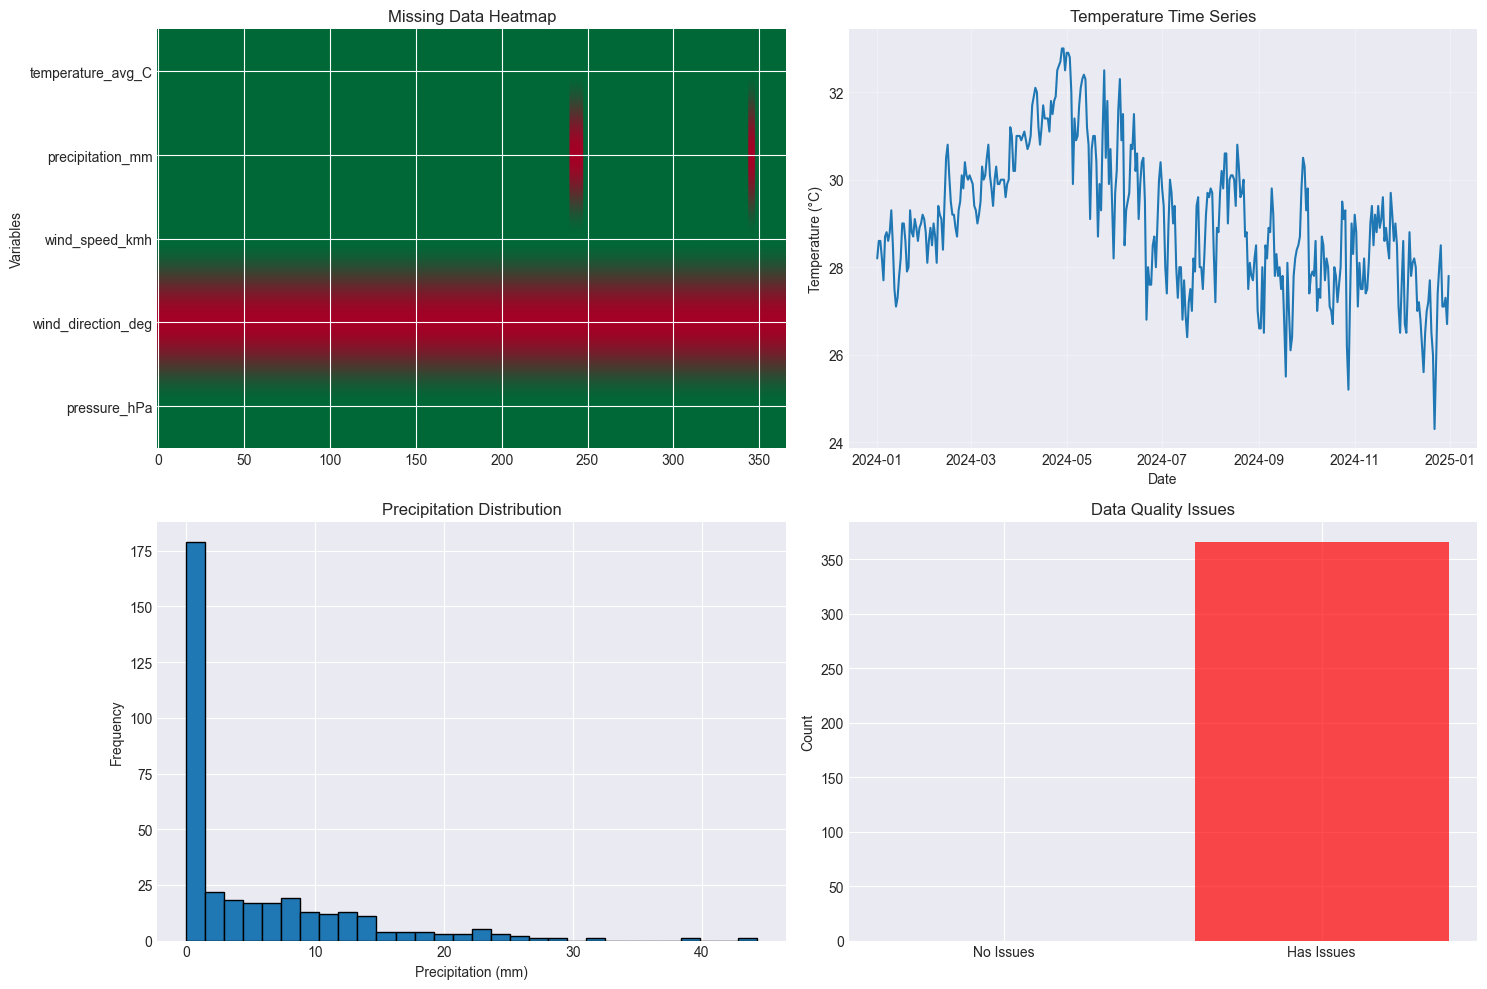

✓ Đã lưu visualization tại: ../reports/weather_qa_visualization.pdf


In [15]:
# Visualize data quality issues
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Missing data heatmap
missing_cols = ['temperature_avg_C', 'precipitation_mm', 'wind_speed_kmh', 
                'wind_direction_deg', 'pressure_hPa']
missing_data_viz = df_weather_output[missing_cols].isnull().astype(int)
axes[0, 0].imshow(missing_data_viz.T, aspect='auto', cmap='RdYlGn_r')
axes[0, 0].set_title('Missing Data Heatmap')
axes[0, 0].set_ylabel('Variables')
axes[0, 0].set_yticks(range(len(missing_cols)))
axes[0, 0].set_yticklabels(missing_cols)

# 2. Temperature time series
axes[0, 1].plot(df_weather_output['time'], df_weather_output['temperature_avg_C'])
axes[0, 1].set_title('Temperature Time Series')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Precipitation distribution
axes[1, 0].hist(df_weather_output['precipitation_mm'].dropna(), bins=30, edgecolor='black')
axes[1, 0].set_title('Precipitation Distribution')
axes[1, 0].set_xlabel('Precipitation (mm)')
axes[1, 0].set_ylabel('Frequency')

# 4. Quality issues distribution
quality_summary = df_weather_output['has_quality_issues'].value_counts()
axes[1, 1].bar(['No Issues', 'Has Issues'], 
               [quality_summary.get(0, 0), quality_summary.get(1, 0)],
               color=['green', 'red'], alpha=0.7)
axes[1, 1].set_title('Data Quality Issues')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/weather_qa_visualization.pdf', bbox_inches='tight')
plt.show()

print("✓ Đã lưu visualization tại: ../reports/weather_qa_visualization.pdf")

## 15. Tóm tắt Cuối cùng

In [16]:
print("="*70)
print("TÓM TẮT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU THỜI TIẾT")
print("="*70)
print(f"\n📁 File gốc: raw/meteostat_weather_data.csv")
print(f"📁 File đã làm sạch: processed/weather_cleaned.csv")
print(f"📁 Báo cáo QA: reports/qa_weather_summary.csv")
print(f"📁 Visualization: reports/weather_qa_visualization.pdf")

print(f"\n📊 Thống kê:")
print(f"  - Tổng số quy tắc kiểm tra: {len(qa_report)}")
print(f"  - Số dòng ban đầu: {len(df_weather_output)}")
print(f"  - Số dòng có vấn đề: {issues_count} ({issues_percentage:.2f}%)")
print(f"  - Số dòng sạch: {len(df_weather_output) - issues_count} ({100-issues_percentage:.2f}%)")

print(f"\n✅ HOÀN TẤT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU THỜI TIẾT!")
print("="*70)

TÓM TẮT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU THỜI TIẾT

📁 File gốc: raw/meteostat_weather_data.csv
📁 File đã làm sạch: processed/weather_cleaned.csv
📁 Báo cáo QA: reports/qa_weather_summary.csv
📁 Visualization: reports/weather_qa_visualization.pdf

📊 Thống kê:
  - Tổng số quy tắc kiểm tra: 2
  - Số dòng ban đầu: 366
  - Số dòng có vấn đề: 366 (100.00%)
  - Số dòng sạch: 0 (0.00%)

✅ HOÀN TẤT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU THỜI TIẾT!
